<a href="https://colab.research.google.com/github/yesufma/solar-challenge-week1/blob/setup-task/Solar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats  # For Z-scores

In [17]:
pip install --upgrade seaborn pandas

In [18]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
import pandas as pd

# Adjust the path based on where your file is in Drive
file_path = '/content/drive/MyDrive/benin-malanville.csv'

df = pd.read_csv(file_path)
df.head()

,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
0,2021-08-09 00:01,-1.2,-0.2,-1.1,0.0,0.0,26.2,93.4,0.0,0.4,0.1,122.1,0.0,998,0,0.0,26.3,26.2,NaN
1,2021-08-09 00:02,-1.1,-0.2,-1.1,0.0,0.0,26.2,93.6,0.0,0.0,0.0,0.0,0.0,998,0,0.0,26.3,26.2,NaN
2,2021-08-09 00:03,-1.1,-0.2,-1.1,0.0,0.0,26.2,93.7,0.3,1.1,0.5,124.6,1.5,997,0,0.0,26.4,26.2,NaN
3,2021-08-09 00:04,-1.1,-0.1,-1.0,0.0,0.0,26.2,93.3,0.2,0.7,0.4,120.3,1.3,997,0,0.0,26.4,26.3,NaN
4,2021-08-09 00:05,-1.0,-0.1,-1.0,0.0,0.0,26.2,93.3,0.1,0.7,0.3,113.2,1.0,997,0,0.0,26.4,26.3,NaN


In [20]:
# Basic statistics
print("Summary Statistics:")
print(df.describe())

# Missing values report
missing_values = df.isna().sum()
missing_percent = (missing_values / len(df)) * 100
print("\nMissing Values (%):")
print(missing_percent.round(2))

Summary Statistics:
                 GHI            DNI            DHI           ModA  \
count  525600.000000  525600.000000  525600.000000  525600.000000   
mean      240.559452     167.187516     115.358961     236.589496   
std       331.131327     261.710501     158.691074     326.894859   
min       -12.900000      -7.800000     -12.600000       0.000000   
25%        -2.000000      -0.500000      -2.100000       0.000000   
50%         1.800000      -0.100000       1.600000       4.500000   
75%       483.400000     314.200000     216.300000     463.700000   
max      1413.000000     952.300000     759.200000    1342.300000   

                ModB           Tamb             RH             WS  \
count  525600.000000  525600.000000  525600.000000  525600.000000   
mean      228.883576      28.179683      54.487969       2.121113   
std       316.536515       5.924297      28.073069       1.603466   
min         0.000000      11.000000       2.100000       0.000000   
25%         0

In [21]:
from scipy import stats  # <-- you need this

# Columns to check (adjust as needed)
columns = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']

# Calculate Z-scores
z_scores = stats.zscore(df[columns])
outliers = (abs(z_scores) > 3).any(axis=1)  # Rows with |Z| > 3

# Remove outliers
df_clean = df[~outliers]
print(f"Removed {outliers.sum()} outliers.")


Removed 7740 outliers.


In [22]:
# Converting Timestamp to DateTime
df_clean['Timestamp'] = pd.to_datetime(df_clean['Timestamp'])

<ipython-input-22-0b8b6e20170d>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Timestamp'] = pd.to_datetime(df_clean['Timestamp'])


<ipython-input-28-c38c3f8f87f5>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Timestamp'] = pd.to_datetime(df_clean['Timestamp'])


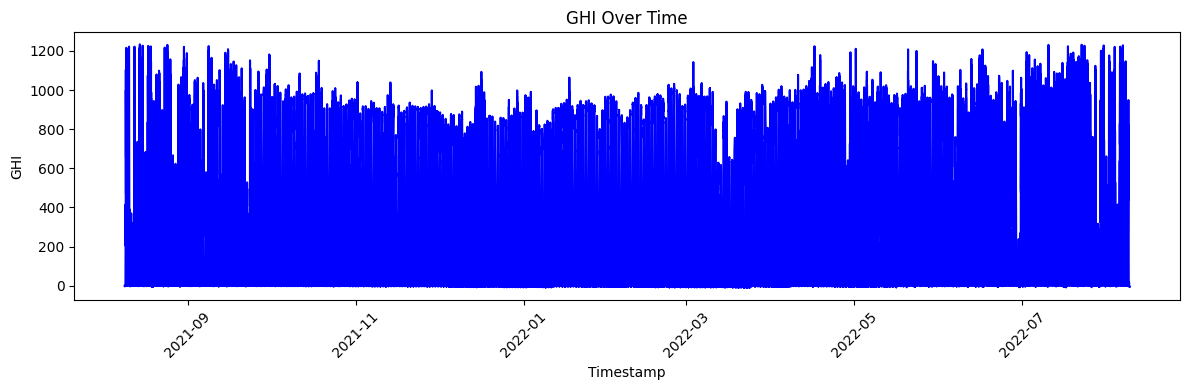

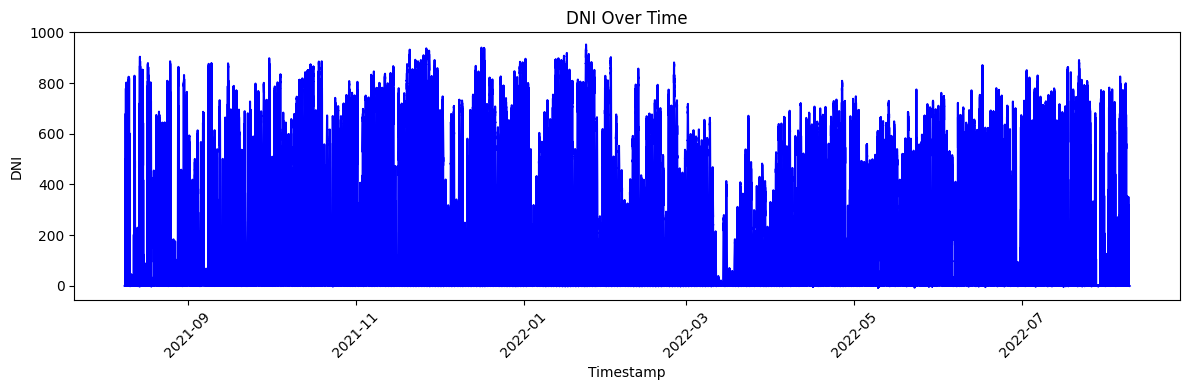

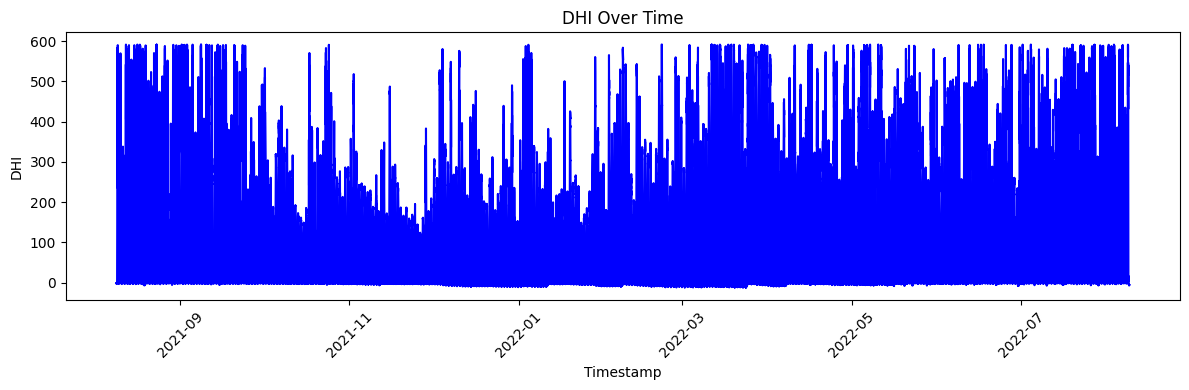

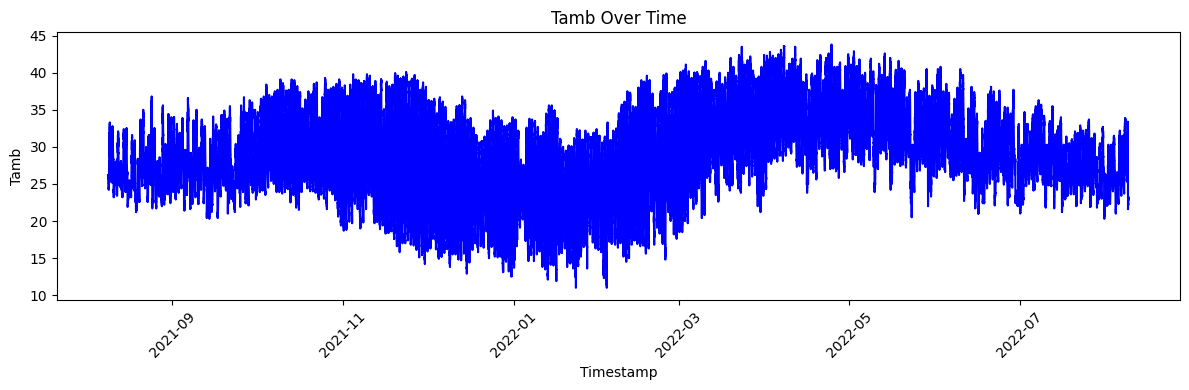

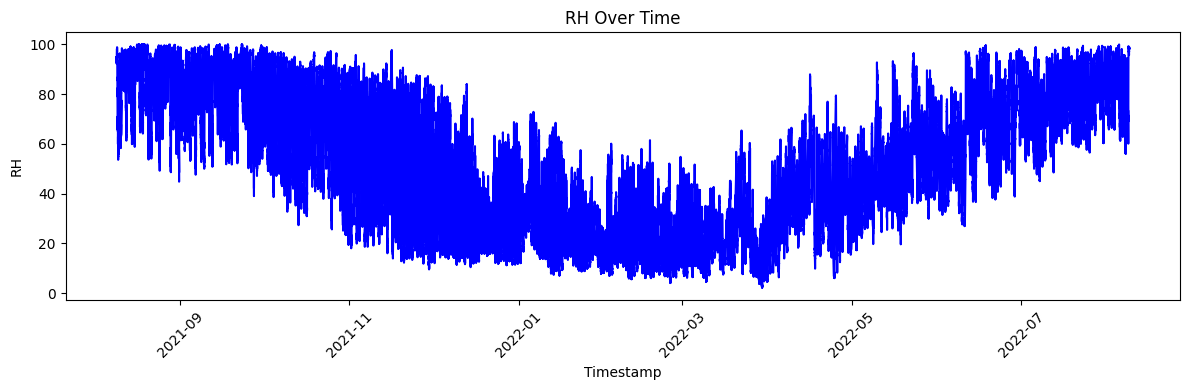

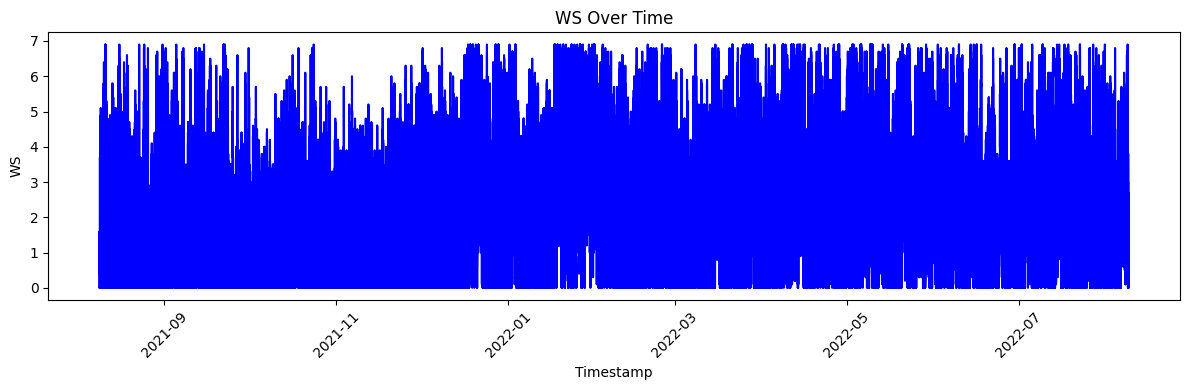

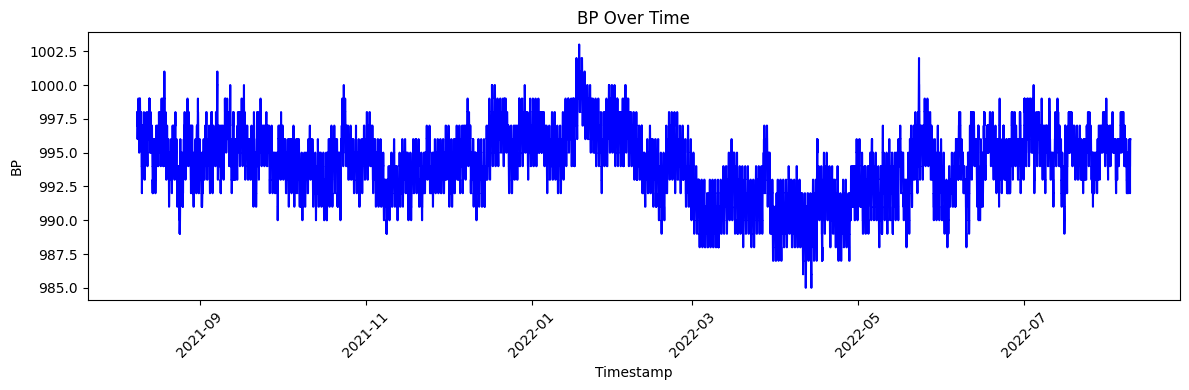

In [28]:
# List of variables to plot
variables = ['GHI', 'DNI', 'DHI', 'Tamb', 'RH', 'WS', 'BP']

# Convert Timestamp to datetime (if not done already)
df_clean['Timestamp'] = pd.to_datetime(df_clean['Timestamp'])

# Loop through each variable and create a separate plot
for var in variables:
    plt.figure(figsize=(12, 4))
    sns.lineplot(x='Timestamp', y=var, data=df_clean, color='blue')
    plt.title(f'{var} Over Time')
    plt.xticks(rotation=45)
    plt.tight_layout()  # Adjust layout to prevent overlapping
    plt.show()

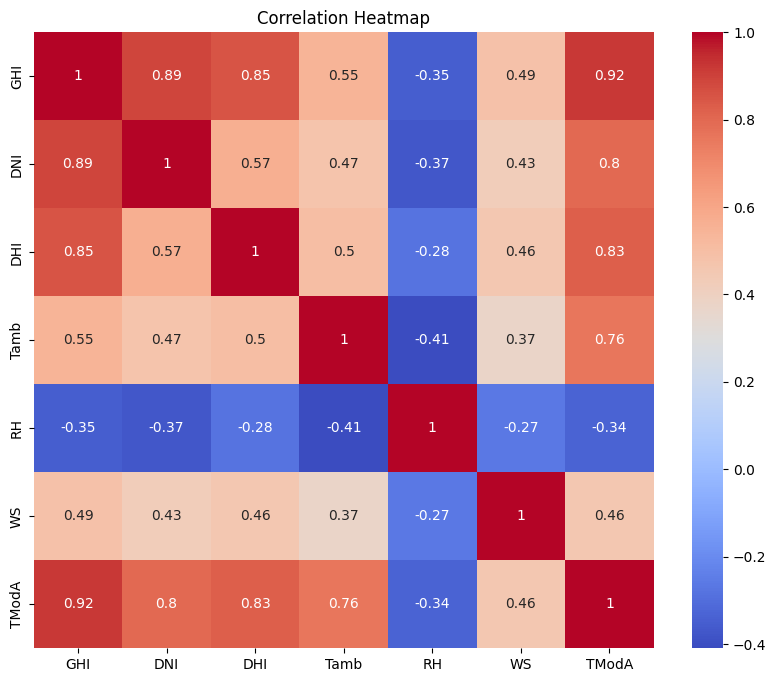

In [29]:
corr_columns = ['GHI', 'DNI', 'DHI', 'Tamb', 'RH', 'WS', 'TModA']
corr_matrix = df_clean[corr_columns].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [33]:
import os

# Define the path in Google Drive
drive_path = "/content/drive/MyDrive/Solar Project/data"

# Create the folder (if it doesn't exist)
os.makedirs(drive_path, exist_ok=True)

In [34]:
# Full path to the CSV file
csv_path = os.path.join(drive_path, "benin_clean.csv")

# Save the DataFrame
df_clean.to_csv(csv_path, index=False)
print(f"File saved to Google Drive: {csv_path}")


File saved to Google Drive: /content/drive/MyDrive/Solar Project/data/benin_clean.csv
